In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('../Dataset/Processed/telco_customer_churn_cleaned.csv')
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

In [6]:
df.describe()

,senior_citizen,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df.describe(include='object')

,customer_id,gender,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [8]:
numerical_columns=df.select_dtypes(include=['int64','float64'])
print(numerical_columns)

      senior_citizen  tenure  monthly_charges  total_charges
0                  0       1            29.85          29.85
1                  0      34            56.95        1889.50
2                  0       2            53.85         108.15
3                  0      45            42.30        1840.75
4                  0       2            70.70         151.65
...              ...     ...              ...            ...
7038               0      24            84.80        1990.50
7039               0      72           103.20        7362.90
7040               0      11            29.60         346.45
7041               1       4            74.40         306.60
7042               0      66           105.65        6844.50

[7043 rows x 4 columns]


In [9]:
categorical_columns = df.select_dtypes(
    include='object'
).columns
print(categorical_columns)


Index(['customer_id', 'gender', 'partner', 'dependents', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'churn'],
      dtype='object')


In [41]:
#Count of Churn values
df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [42]:
#count of gender values
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [11]:
df['churn'].value_counts(normalize=True)*100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

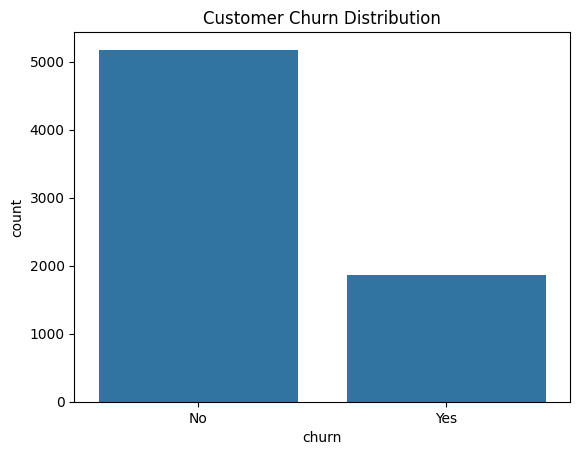

In [44]:
sns.countplot(
    x='churn',
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

In [13]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

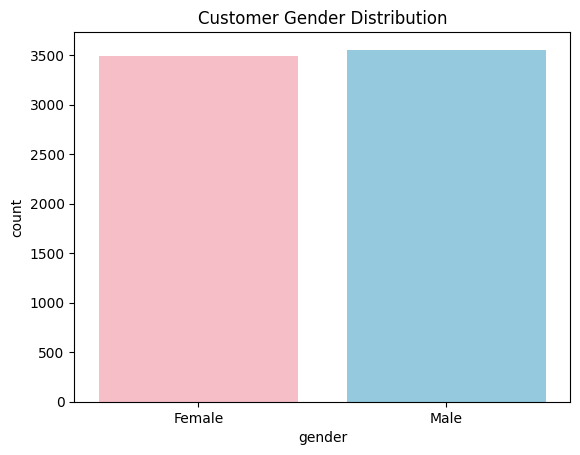

In [14]:
sns.countplot(
    x='gender',
    data=df,
    palette=['#FFB6C1', '#87CEEB']  
)

plt.title("Customer Gender Distribution")
plt.show()

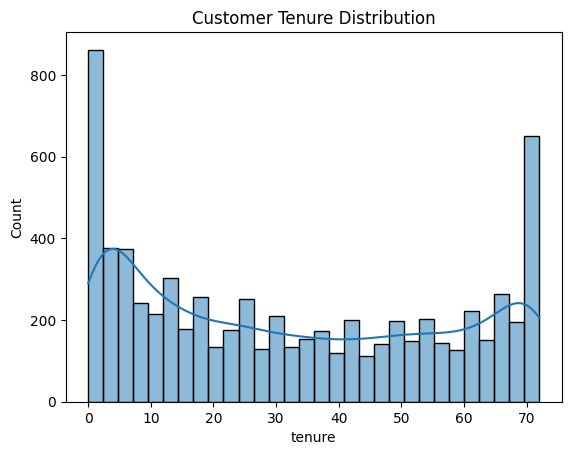

In [46]:
#tenure distribution
sns.histplot( df['tenure'], bins=(30), kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

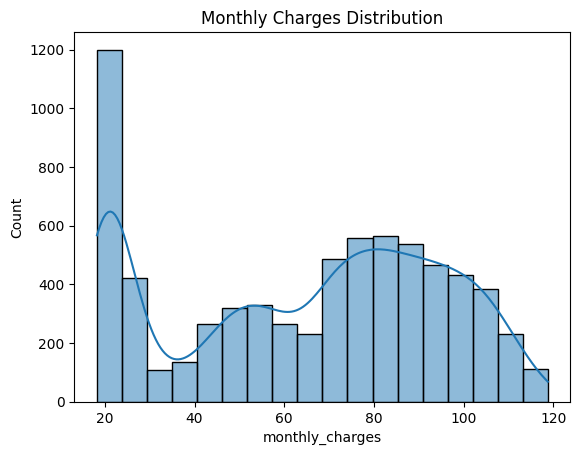

In [16]:
sns.histplot(
    df['monthly_charges'],
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.show()

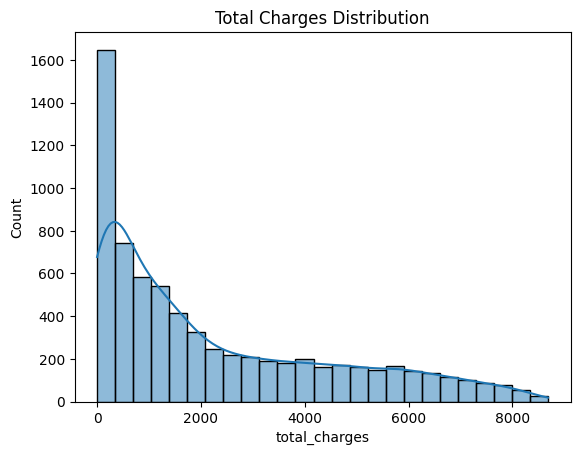

In [17]:
sns.histplot(
    df['total_charges'],
    kde=True
)

plt.title("Total Charges Distribution")
plt.show()

BIVARIATE EDA

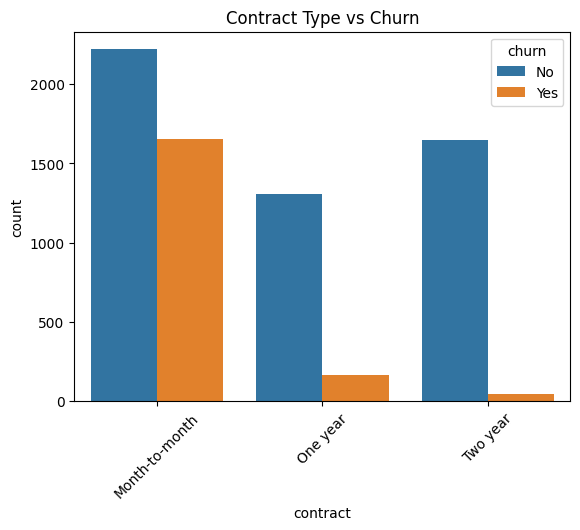

In [ ]:
sns.countplot(
    x='contract',
    hue='churn',
    data=df
)

plt.xticks(rotation=45)
plt.title("Contract Type vs Churn")
plt.show()

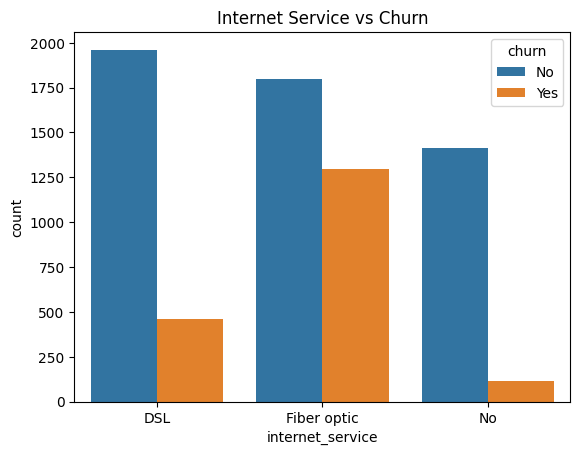

In [19]:
sns.countplot(
    x='internet_service',
    hue='churn',
    data=df
)

plt.title("Internet Service vs Churn")
plt.show()

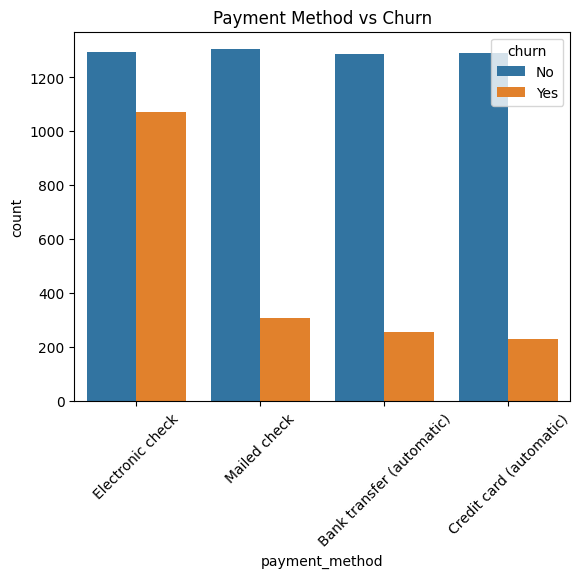

In [20]:
sns.countplot(
    x='payment_method',
    hue='churn',
    data=df
)

plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

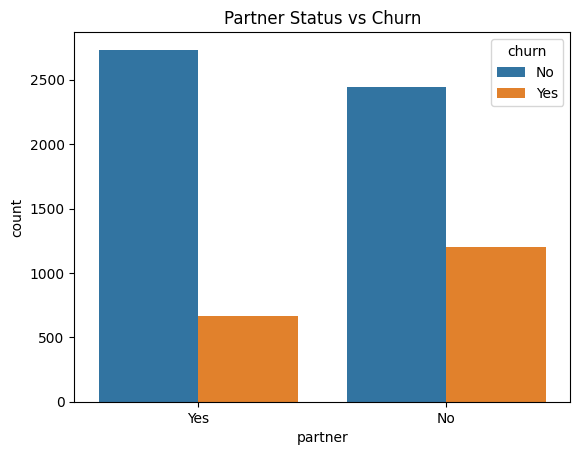

In [ ]:
sns.countplot(
    x='partner',
    hue='churn',
    data=df
)
plt.title("Partner Status vs Churn")
plt.show()

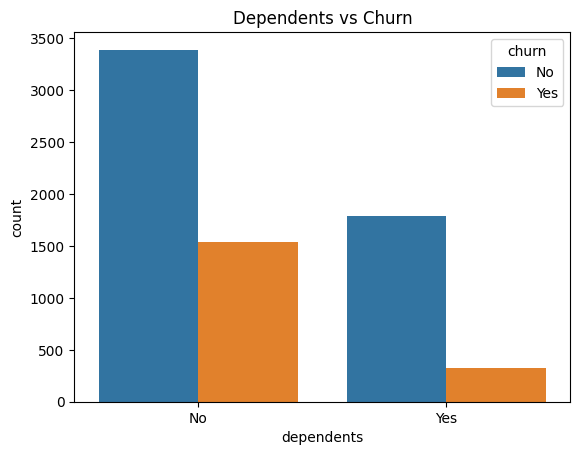

In [22]:
sns.countplot(
    x='dependents',
    hue='churn',
    data=df
)

plt.title("Dependents vs Churn")
plt.show()

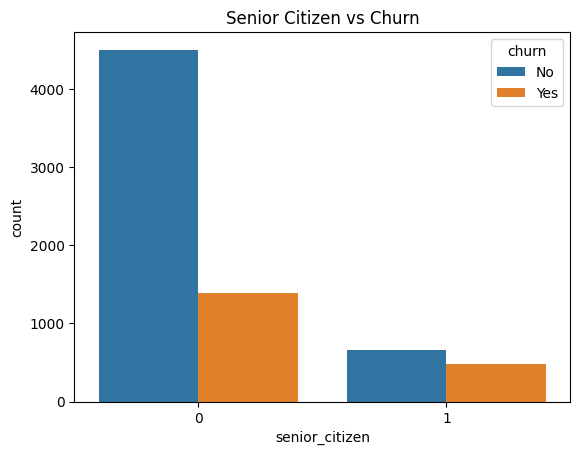

In [23]:
sns.countplot(
    x='senior_citizen',
    hue='churn',
    data=df
)

plt.title("Senior Citizen vs Churn")
plt.show()

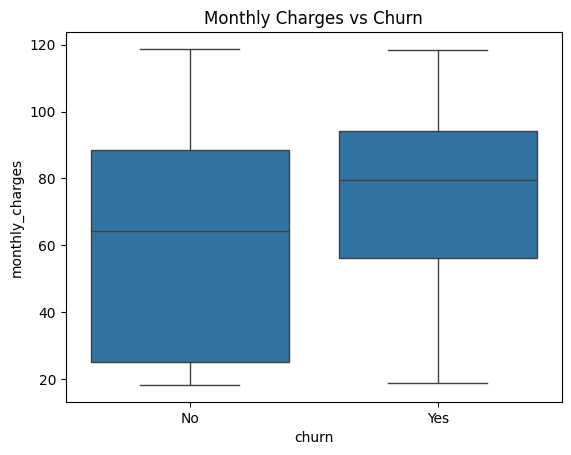

In [ ]:
sns.boxplot(
    x='churn',
    y='monthly_charges',
    data=df
)
plt.title("Monthly Charges vs Churn")
plt.show()

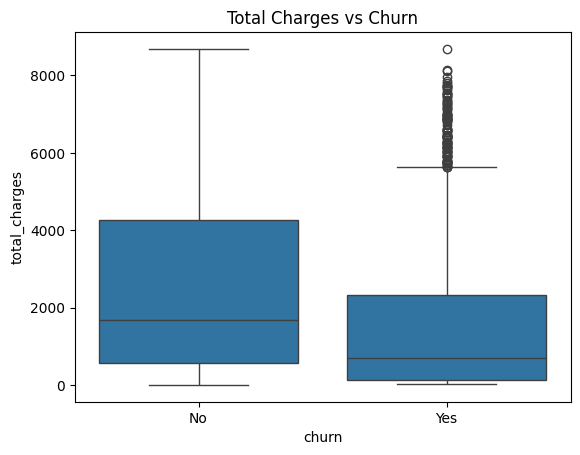

In [ ]:
sns.boxplot(
    x='churn',
    y='total_charges',
    data=df
)
plt.title("Total Charges vs Churn")
plt.show()

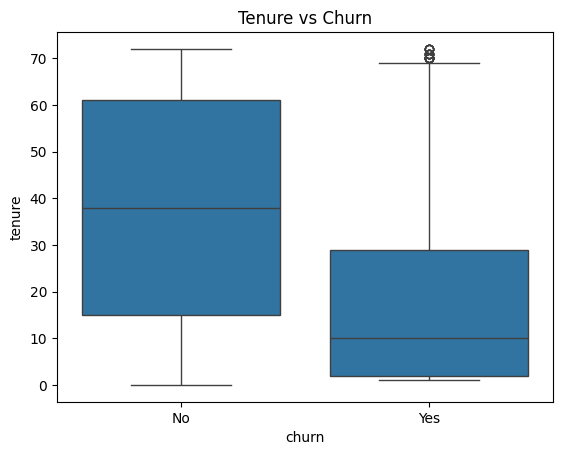

In [ ]:
sns.boxplot(
    x='churn',
    y='tenure',
    data=df
)
plt.title("Tenure vs Churn")
plt.show()

In [27]:
df['churn_binary'] = df['churn'].map({
    'No':0,
    'Yes':1
})

In [28]:
correlation = df.corr(
    numeric_only=True
)

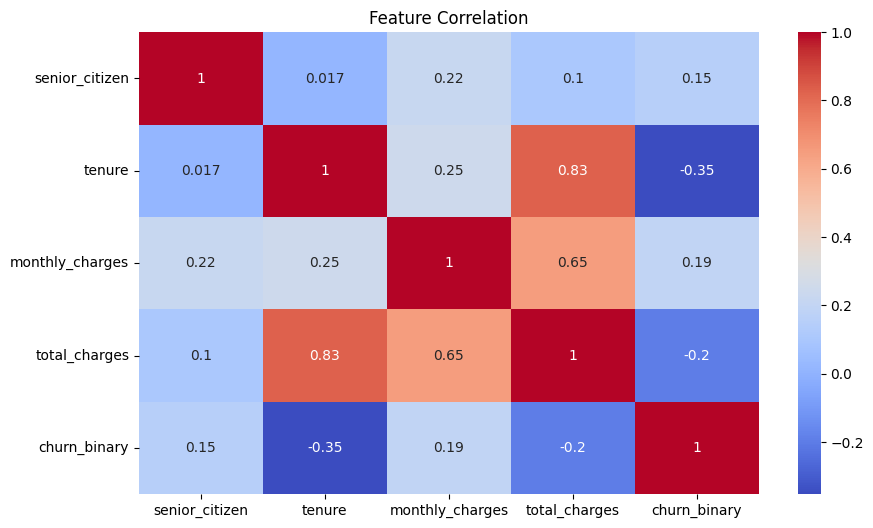

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation")
plt.show()

In [30]:
revenue_loss = df[
    df['churn']=='Yes'
]['total_charges'].sum()

print(revenue_loss)

2862926.9


In [31]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=[
        '0-1 Year',
        '1-2 Years',
        '2-4 Years',
        '4-6 Years'
    ]
)

In [32]:
pd.crosstab(
    df['tenure_group'],
    df['churn']
)

churn,No,Yes
tenure_group,,
0-1 Year,1138,1037
1-2 Years,730,294
2-4 Years,1269,325
4-6 Years,2026,213


<Axes: xlabel='tenure_group', ylabel='count'>

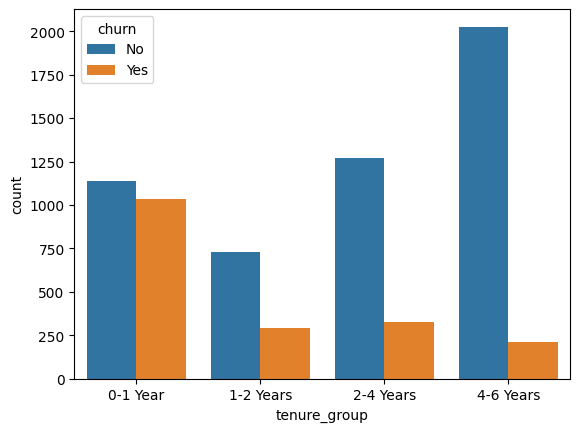

In [33]:
sns.countplot(
    x='tenure_group',
    hue='churn',
    data=df
)